In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve
from matplotlib.ticker import MaxNLocator
import dcor

# CATHODE, CDOT, LaCATHODE Plots Production

This jupyter notebook reads in the data produced from the "data production" jupyter notebook and produces useful plots using it.

# Importing Data

In [3]:
train_df = pd.read_pickle("./train.pkl")

val_df = pd.read_pickle("./val.pkl")

test_df = pd.read_pickle("./test.pkl")

cathode_samples_df = pd.read_pickle("./cathode_samples.pkl")

latent_train_df = pd.read_pickle("./LaCATHODE_train.pkl")

latent_sample_df = pd.read_pickle("./LaCATHODE_samples.pkl")

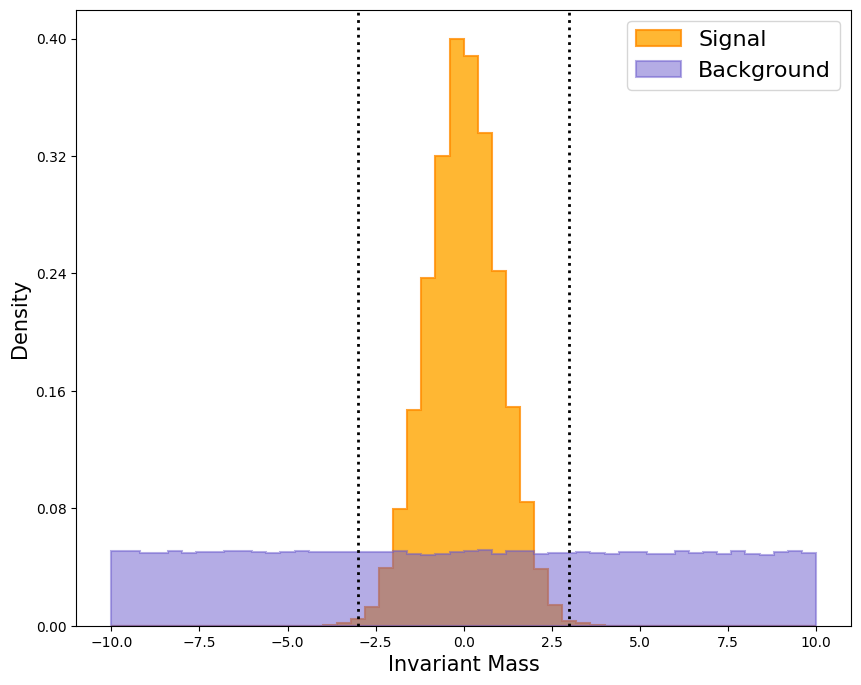

In [4]:
fig, axs = plt.subplots(1, 1, figsize = (10,8))

bins = np.linspace(-10, 10, 51)  # 51 edges = 50 bins

axs.yaxis.set_major_locator(MaxNLocator(6))

axs.hist(test_df[test_df["signal"]==1]["m"],
            bins = bins,
            label = "Signal",
            histtype = "stepfilled",
            color = "orange",
            edgecolor = "darkorange",
            alpha = 0.8,
            linewidth = 1.5,
            density = True)

axs.hist(test_df[test_df["signal"]==0]["m"],
            bins = bins,
            label = "Background",
            histtype = "stepfilled",
            color = "slateblue",
            edgecolor = "slateblue",
            alpha = 0.5,
            linewidth = 1.5,
            density = True
            )

axs.axvline(x=-3, linestyle=":", color="black", linewidth=2)
axs.axvline(x=3, linestyle=":", color="black", linewidth=2)

leg_0 = axs.legend(prop = {'size': 16})
title0 = leg_0.get_title()
title0.set_fontsize(10)
title0.set_fontweight('bold')
title0.set_position((-42.5, 0))

axs.set_xlabel("Invariant Mass", fontsize = 15)
axs.set_ylabel("Density", fontsize = 15)

fig.savefig('Pres_simulated_data.png', bbox_inches='tight')

plt.show()


# First Set of Cut Plots

no_cut: Signal-to-Backgound ratio 0.11246954645070141
h: Signal-to-Backgound ratio 0.7441427823963723
trans_h: Signal-to-Backgound ratio 1.5345104333868378
la_h: Signal-to-Backgound ratio 1.630512932924156
no_cut: Signal-to-Backgound ratio 0.11246954645070141
h: Signal-to-Backgound ratio 0.7441427823963723
trans_h: Signal-to-Backgound ratio 1.5345104333868378
la_h: Signal-to-Backgound ratio 1.630512932924156


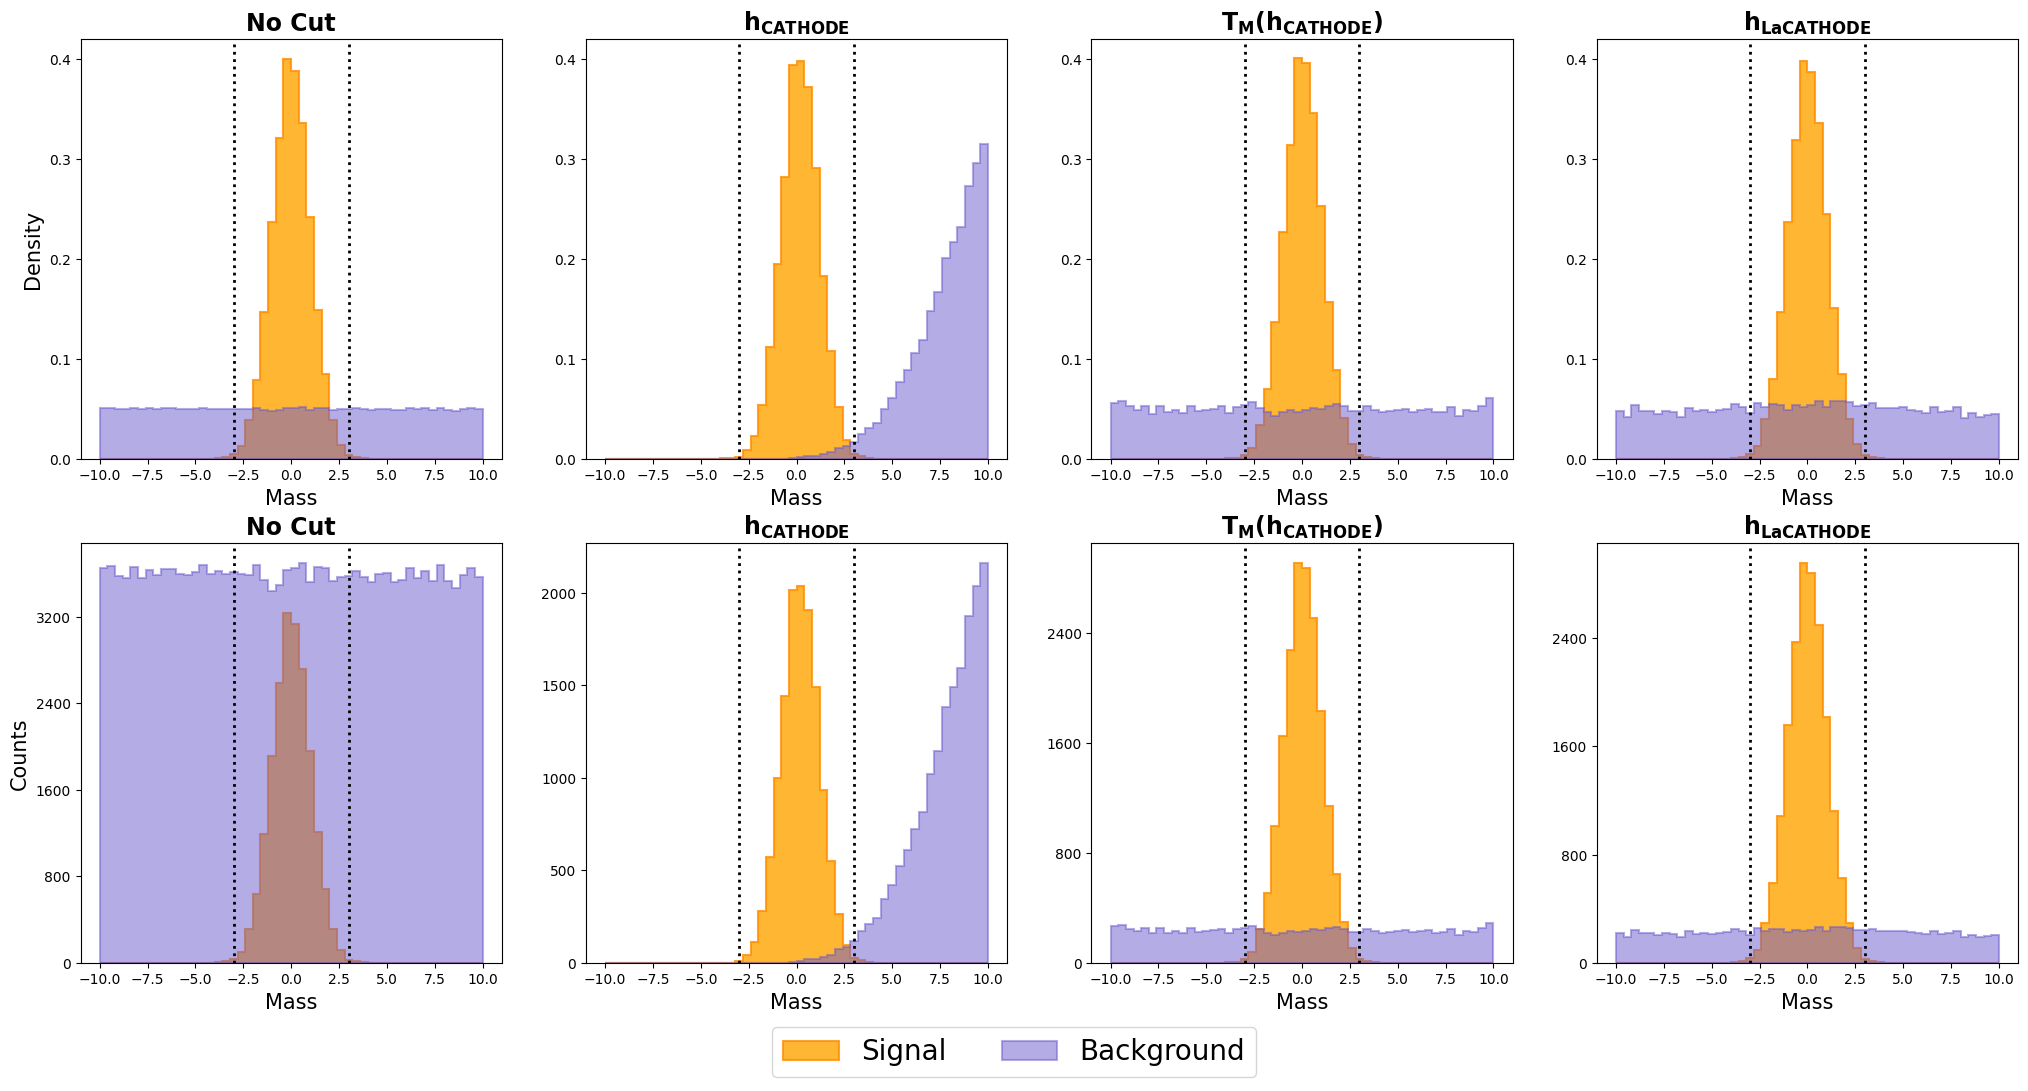

In [5]:
# Assign which classifier output you want to use
h = ("no_cut", "h", "trans_h", "la_h")     # Pre-CDOT classifier output

titles = ("No Cut", r"$\mathbf{h_{CATHODE}}$", r"$\mathbf{T_M(h_{CATHODE})}$",  r"$\mathbf{h_{LaCATHODE}}$")

fig, axs = plt.subplots(2, len(h), figsize = (25,12))

bins = np.linspace(-10, 10, 51)  # 51 edges = 50 bins

# for ax in axs.flatten():                                  # Uncomment to show numbers across all the y-axes
#     ax.tick_params(labelbottom=True, labelleft=True)


for ax in axs.flatten():
    ax.yaxis.set_major_locator(MaxNLocator(5))

thresh = 0.85

density_flag = (True, False)

y_label = ["Density", "Counts"]

# y-axis label
axs[0,0].set_ylabel("Density", fontsize = 15)
axs[1,0].set_ylabel("Counts", fontsize = 15)

for i in range(axs.shape[0]):
    # Assign the plot to be a density plot or a histogram
    density = density_flag[i]
    for j in range(axs.shape[1]):

        # Set the range of classifier outputs accepted for the plot
        if h[j] != "no_cut":
            cutdata = test_df[(test_df[h[j]] >= np.quantile(test_df[h[j]], thresh))]
        else:
            cutdata = test_df

        axs[i,j].hist(cutdata[cutdata["signal"]==1]["m"],
            bins = bins,
            label = "Signal",
            histtype = "stepfilled",
            color = "orange",
            edgecolor = "darkorange",
            alpha = 0.8,
            linewidth = 1.5,
            density = density)
        
        axs[i,j].hist(cutdata[cutdata["signal"]==0]["m"],
            bins = bins,
            label = "Background",
            histtype = "stepfilled",
            color = "slateblue",
            edgecolor = "slateblue",
            alpha = 0.5,
            linewidth = 1.5,
            density = density
            )
        
        axs[i,j].set_xlabel("Mass", fontsize = 15)
        axs[i,j].set_title(titles[j], fontsize = 17, fontweight = "bold")

        axs[i,j].axvline(x=-3, linestyle=":", color="black", linewidth=2)
        axs[i,j].axvline(x=3, linestyle=":", color="black", linewidth=2)

        lambda_hat = len(cutdata[cutdata["signal"]==1]) / len(cutdata[cutdata["signal"]==0])

        print(f"{h[j]}: Signal-to-Backgound ratio {lambda_hat}")

# share y-axis only across first row
for ax in axs[0, 1:]:
    ax.sharey(axs[0, 0])

h, l = axs[0,0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2, prop={'size': 20})

fig.savefig('Pres_Unsupervised_Cuts_Correlated.png', bbox_inches='tight')

plt.show()


no_cut: Signal-to-Backgound ratio 0.11246954645070141
h: Signal-to-Backgound ratio 0.7441427823963723
trans_h: Signal-to-Backgound ratio 1.5345104333868378
inv_trans_h: Signal-to-Backgound ratio 1.5345104333868378
la_h: Signal-to-Backgound ratio 1.630512932924156
no_cut: Signal-to-Backgound ratio 0.11246954645070141
h: Signal-to-Backgound ratio 0.7441427823963723
trans_h: Signal-to-Backgound ratio 1.5345104333868378
inv_trans_h: Signal-to-Backgound ratio 1.5345104333868378
la_h: Signal-to-Backgound ratio 1.630512932924156


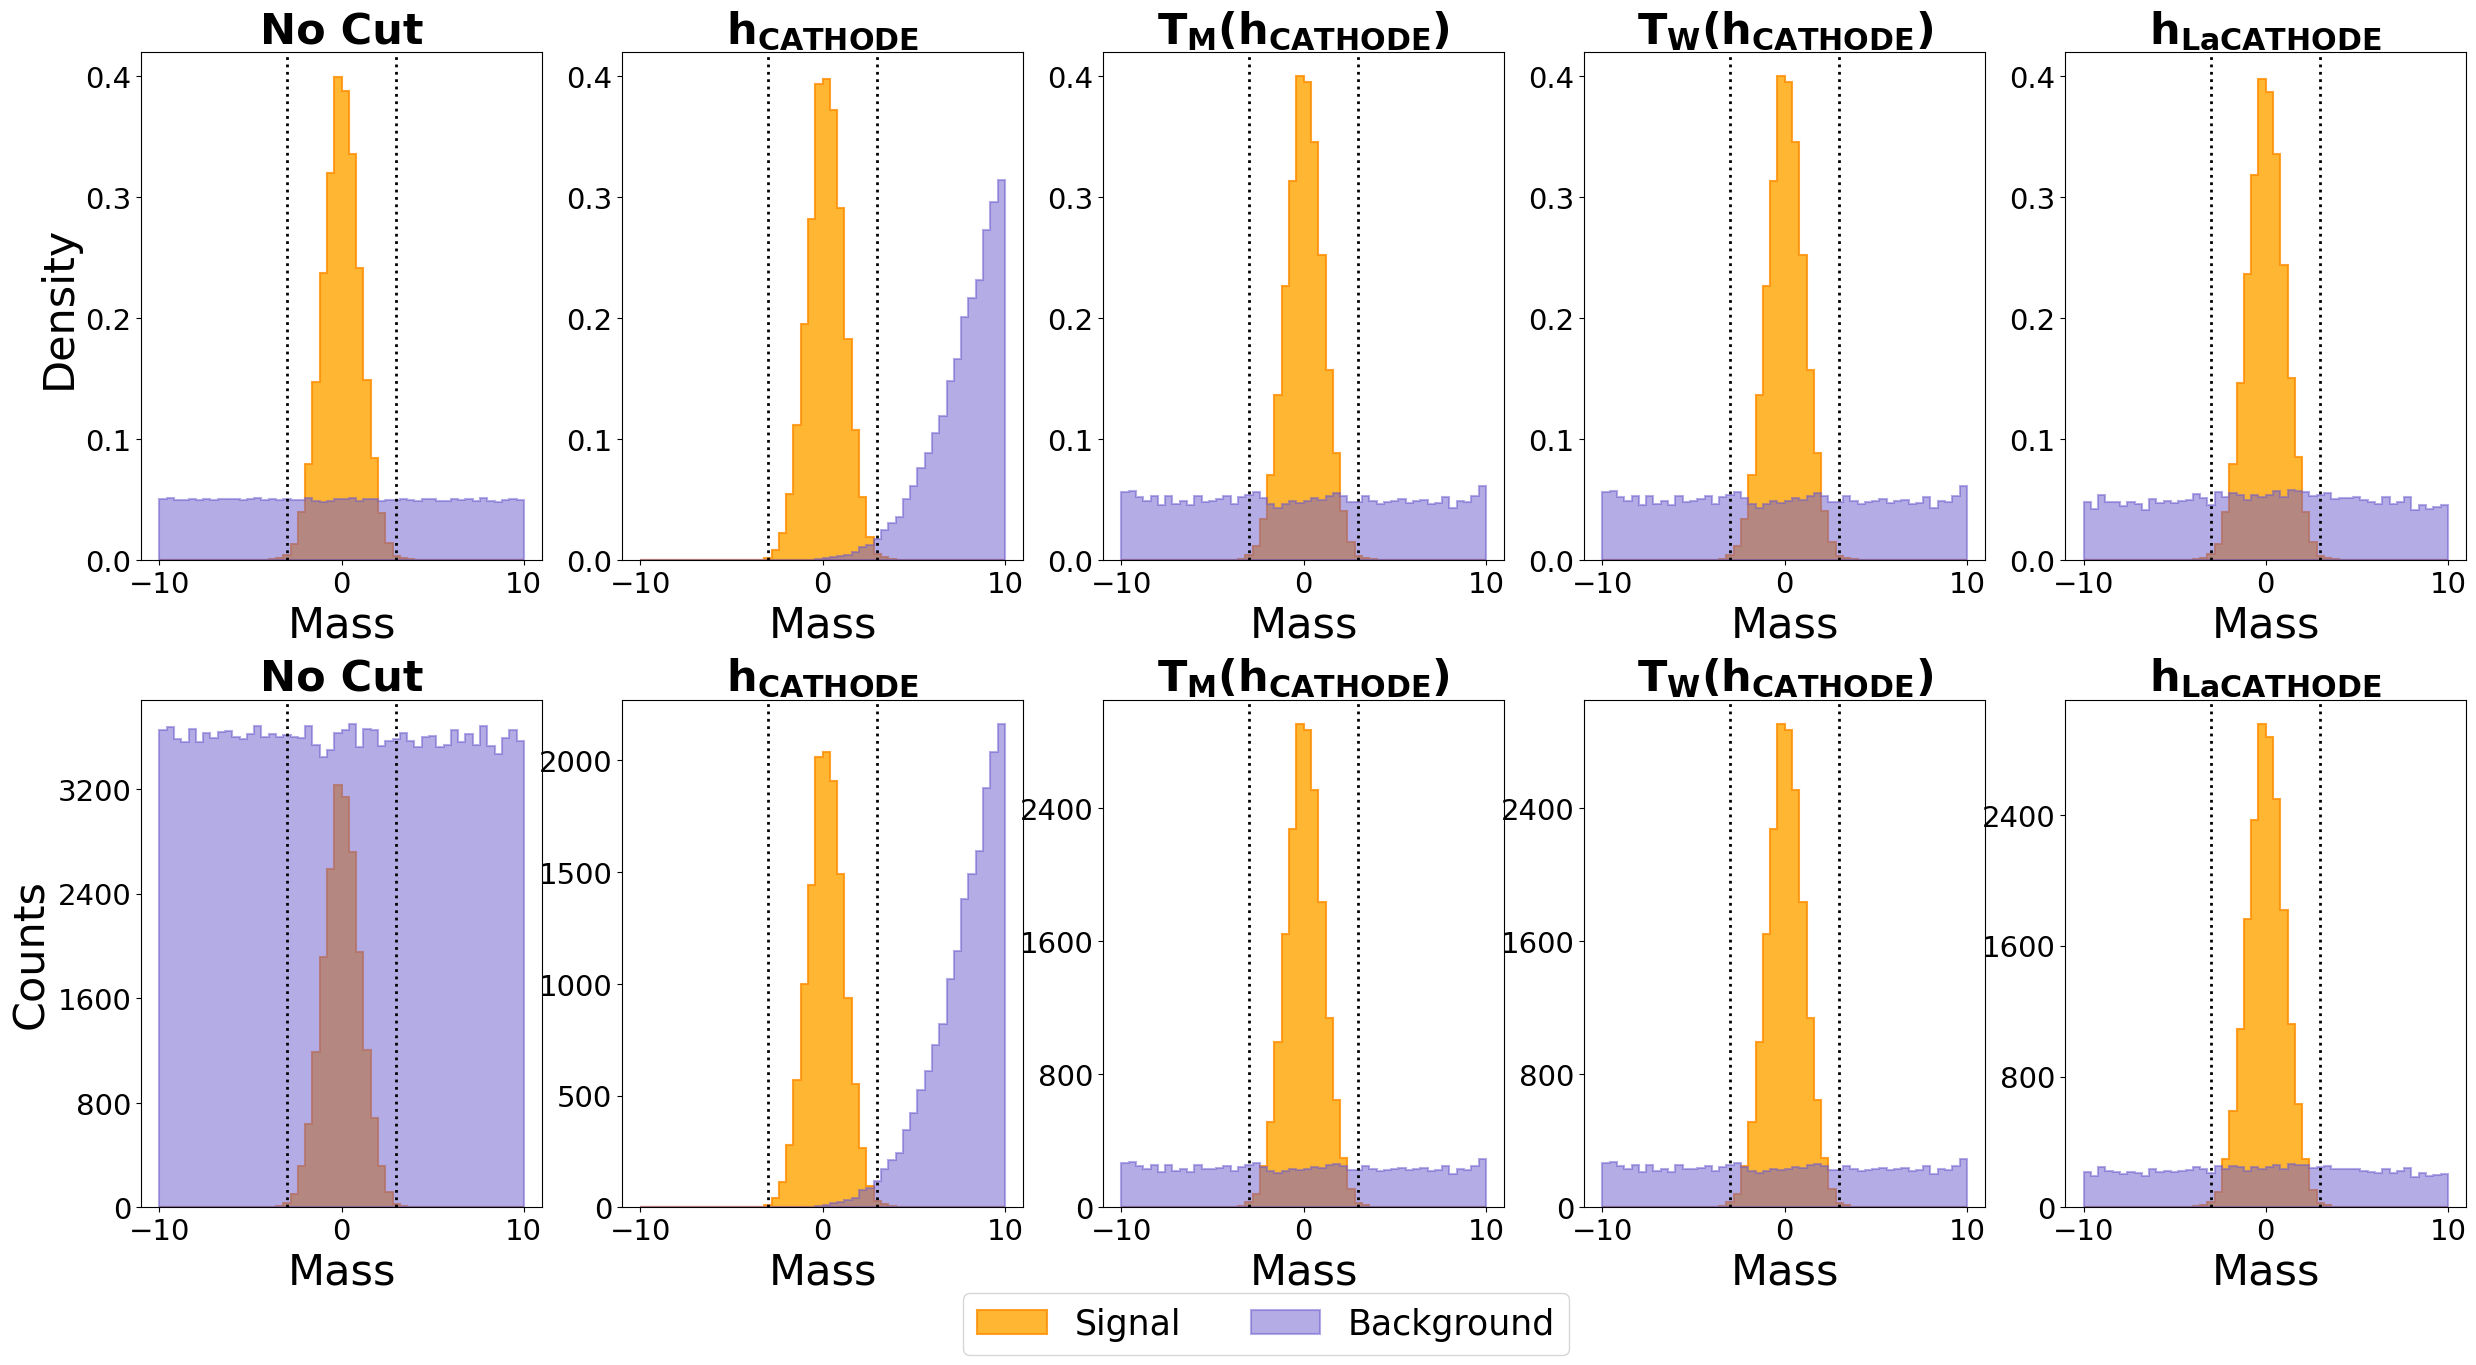

In [6]:
# Assign which classifier output you want to use
h = ("no_cut", "h", "trans_h", "inv_trans_h", "la_h")     # Pre-CDOT classifier output

titles = ("No Cut", r"$\mathbf{h_{CATHODE}}$", r"$\mathbf{T_M(h_{CATHODE})}$", r"$\mathbf{T_W(h_{CATHODE})}$",  r"$\mathbf{h_{LaCATHODE}}$")

fig, axs = plt.subplots(2, len(h), figsize = (30,15))

bins = np.linspace(-10, 10, 51)  # 51 edges = 50 bins

# for ax in axs.flatten():                                  # Uncomment to show numbers across all the y-axes
#     ax.tick_params(labelbottom=True, labelleft=True)


for ax in axs.flatten():
    ax.yaxis.set_major_locator(MaxNLocator(5))

thresh = 0.85

density_flag = (True, False)

y_label = ["Density", "Counts"]

# y-axis label
axs[0,0].set_ylabel("Density", fontsize = 31)
axs[1,0].set_ylabel("Counts", fontsize = 31)

for i in range(axs.shape[0]):
    # Assign the plot to be a density plot or a histogram
    density = density_flag[i]
    for j in range(axs.shape[1]):

        # Set the range of classifier outputs accepted for the plot
        if h[j] != "no_cut":
            cutdata = test_df[(test_df[h[j]] >= np.quantile(test_df[h[j]], thresh))]
        else:
            cutdata = test_df

        axs[i,j].hist(cutdata[cutdata["signal"]==1]["m"],
            bins = bins,
            label = "Signal",
            histtype = "stepfilled",
            color = "orange",
            edgecolor = "darkorange",
            alpha = 0.8,
            linewidth = 1.5,
            density = density)
        
        axs[i,j].hist(cutdata[cutdata["signal"]==0]["m"],
            bins = bins,
            label = "Background",
            histtype = "stepfilled",
            color = "slateblue",
            edgecolor = "slateblue",
            alpha = 0.5,
            linewidth = 1.5,
            density = density
            )
        
        # Axis numbers font size
        axs[i,j].tick_params(axis='x', labelsize=21)
        axs[i,j].tick_params(axis='y', labelsize=21)

        # Axis Label font size
        axs[i,j].set_xlabel("Mass", fontsize = 31)
        axs[i,j].set_title(titles[j], fontsize = 31, fontweight = "bold")

        axs[i,j].axvline(x=-3, linestyle=":", color="black", linewidth=2)
        axs[i,j].axvline(x=3, linestyle=":", color="black", linewidth=2)

        lambda_hat = len(cutdata[cutdata["signal"]==1]) / len(cutdata[cutdata["signal"]==0])

        print(f"{h[j]}: Signal-to-Backgound ratio {lambda_hat}")

# share y-axis only across first row
for ax in axs[0, 1:]:
    ax.sharey(axs[0, 0])

h, l = axs[0,0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2, prop={'size': 25}, bbox_to_anchor=(0.5, 0))

# Vertical Space between the subplots
fig.subplots_adjust(hspace=0.275)

fig.savefig('Unsupervised_Cuts_Correlated.png', bbox_inches='tight')

plt.show()


no_cut: Signal-to-Backgound ratio 0.11246954645070141
ideal_h: Signal-to-Backgound ratio 0.7482081463784162
trans_ideal_h: Signal-to-Backgound ratio 1.7579518293804008
no_cut: Signal-to-Backgound ratio 0.11246954645070141
ideal_h: Signal-to-Backgound ratio 0.7482081463784162
trans_ideal_h: Signal-to-Backgound ratio 1.7579518293804008


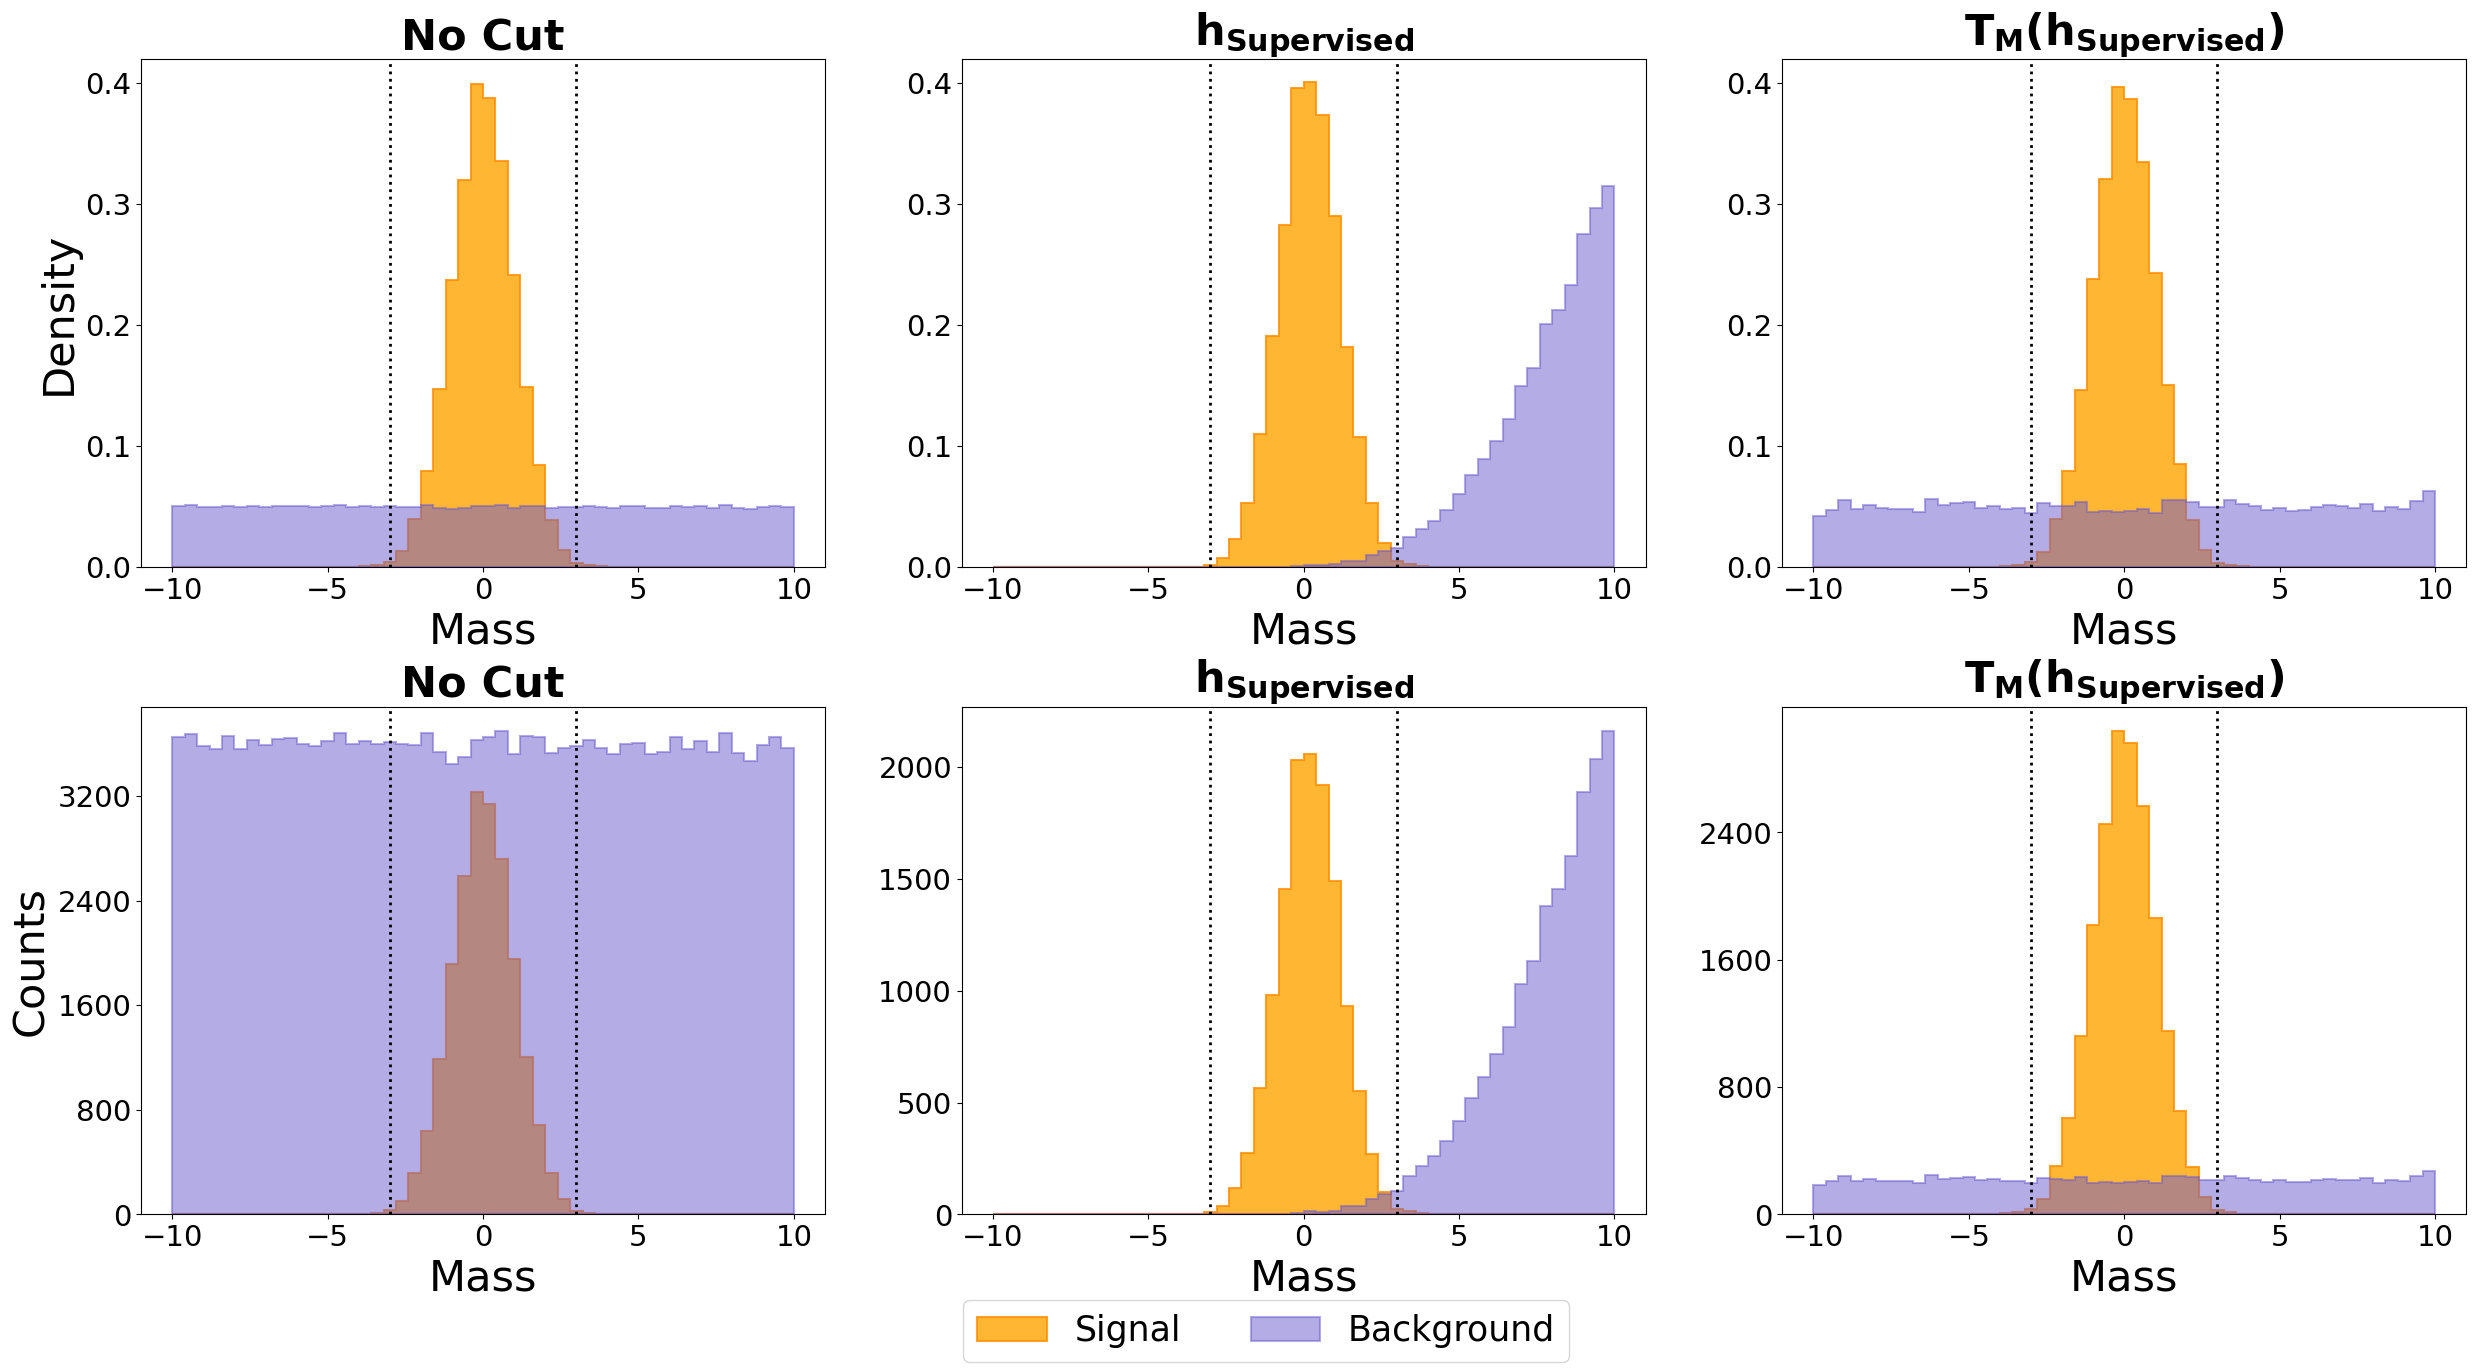

In [7]:
# Assign which classifier output you want to use
h = ("no_cut", "ideal_h", "trans_ideal_h")     # Pre-CDOT classifier output

titles = ("No Cut", r"$\mathbf{h_{Supervised}}$", r"$\mathbf{T_M(h_{Supervised})}$")

fig, axs = plt.subplots(2, len(h), figsize = (30,15))

bins = np.linspace(-10, 10, 51)  # 51 edges = 50 bins

# for ax in axs.flatten():                                  # Uncomment to show numbers across all the y-axes
#     ax.tick_params(labelbottom=True, labelleft=True)


for ax in axs.flatten():
    ax.yaxis.set_major_locator(MaxNLocator(5))

thresh = 0.85

density_flag = (True, False)

y_label = ["Density", "Counts"]

# y-axis label
axs[0,0].set_ylabel("Density", fontsize = 31)
axs[1,0].set_ylabel("Counts", fontsize = 31)

for i in range(axs.shape[0]):
    # Assign the plot to be a density plot or a histogram
    density = density_flag[i]
    for j in range(axs.shape[1]):

        # Set the range of classifier outputs accepted for the plot
        if h[j] != "no_cut":
            cutdata = test_df[(test_df[h[j]] >= np.quantile(test_df[h[j]], thresh))]
        else:
            cutdata = test_df

        axs[i,j].hist(cutdata[cutdata["signal"]==1]["m"],
            bins = bins,
            label = "Signal",
            histtype = "stepfilled",
            color = "orange",
            edgecolor = "darkorange",
            alpha = 0.8,
            linewidth = 1.5,
            density = density)
        
        axs[i,j].hist(cutdata[cutdata["signal"]==0]["m"],
            bins = bins,
            label = "Background",
            histtype = "stepfilled",
            color = "slateblue",
            edgecolor = "slateblue",
            alpha = 0.5,
            linewidth = 1.5,
            density = density
            )
        
        # Axis numbers font size
        axs[i,j].tick_params(axis='x', labelsize=21)
        axs[i,j].tick_params(axis='y', labelsize=21)

        # Axis Label font size
        axs[i,j].set_xlabel("Mass", fontsize = 31)
        axs[i,j].set_title(titles[j], fontsize = 31, fontweight = "bold")

        axs[i,j].axvline(x=-3, linestyle=":", color="black", linewidth=2)
        axs[i,j].axvline(x=3, linestyle=":", color="black", linewidth=2)

        lambda_hat = len(cutdata[cutdata["signal"]==1]) / len(cutdata[cutdata["signal"]==0])

        print(f"{h[j]}: Signal-to-Backgound ratio {lambda_hat}")

# share y-axis only across first row
for ax in axs[0, 1:]:
    ax.sharey(axs[0, 0])

h, l = axs[0,0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2, prop={'size': 25}, bbox_to_anchor=(0.5, 0))

# Vertical Space between the subplots
fig.subplots_adjust(hspace=0.275)

fig.savefig('Supervised_Cuts_Correlated.png', bbox_inches='tight')

plt.show()

In [8]:

with np.errstate(divide='ignore', invalid='ignore'):
    # Classifier Outputs (Pre-CDOT)
    h_fpr, h_tpr, _ = roc_curve(test_df["signal"], test_df["h"])
    h_sic = h_tpr / np.sqrt(h_fpr)

    # Transformed Classifier outputs (Post-CDOT)
    trans_h_fpr, trans_h_tpr, _ = roc_curve(test_df["signal"], test_df["trans_h"])
    trans_h_sic = trans_h_tpr / np.sqrt(trans_h_fpr)

    # Inverse Transformed Classifier outputs (Post-CDOT)
    inv_trans_h_fpr, inv_trans_h_tpr, _ = roc_curve(test_df["signal"], test_df["inv_trans_h"])
    inv_trans_h_sic = inv_trans_h_tpr / np.sqrt(inv_trans_h_fpr)

    # LaCATHODE classifier outputs
    la_h_fpr, la_h_tpr, _ = roc_curve(test_df[~np.isnan(test_df["la_h"])]["signal"], test_df[~np.isnan(test_df["la_h"])]["la_h"])
    la_h_sic = la_h_tpr / np.sqrt(la_h_fpr)

    # Idealised Classifier Outputs (Pre-CDOT)
    ideal_h_fpr, ideal_h_tpr, _ = roc_curve(test_df["signal"], test_df["ideal_h"])
    ideal_h_sic = ideal_h_tpr / np.sqrt(ideal_h_fpr)

    # Idealised Classifier Outputs (Post-CDOT)
    trans_ideal_h_fpr, trans_ideal_h_tpr, _ = roc_curve(test_df["signal"], test_df["trans_ideal_h"])
    trans_ideal_h_sic = trans_ideal_h_tpr / np.sqrt(trans_ideal_h_fpr)

    # Random Line
    random_tpr = np.linspace(0, 1, 300)
    random_sic = random_tpr / np.sqrt(random_tpr)

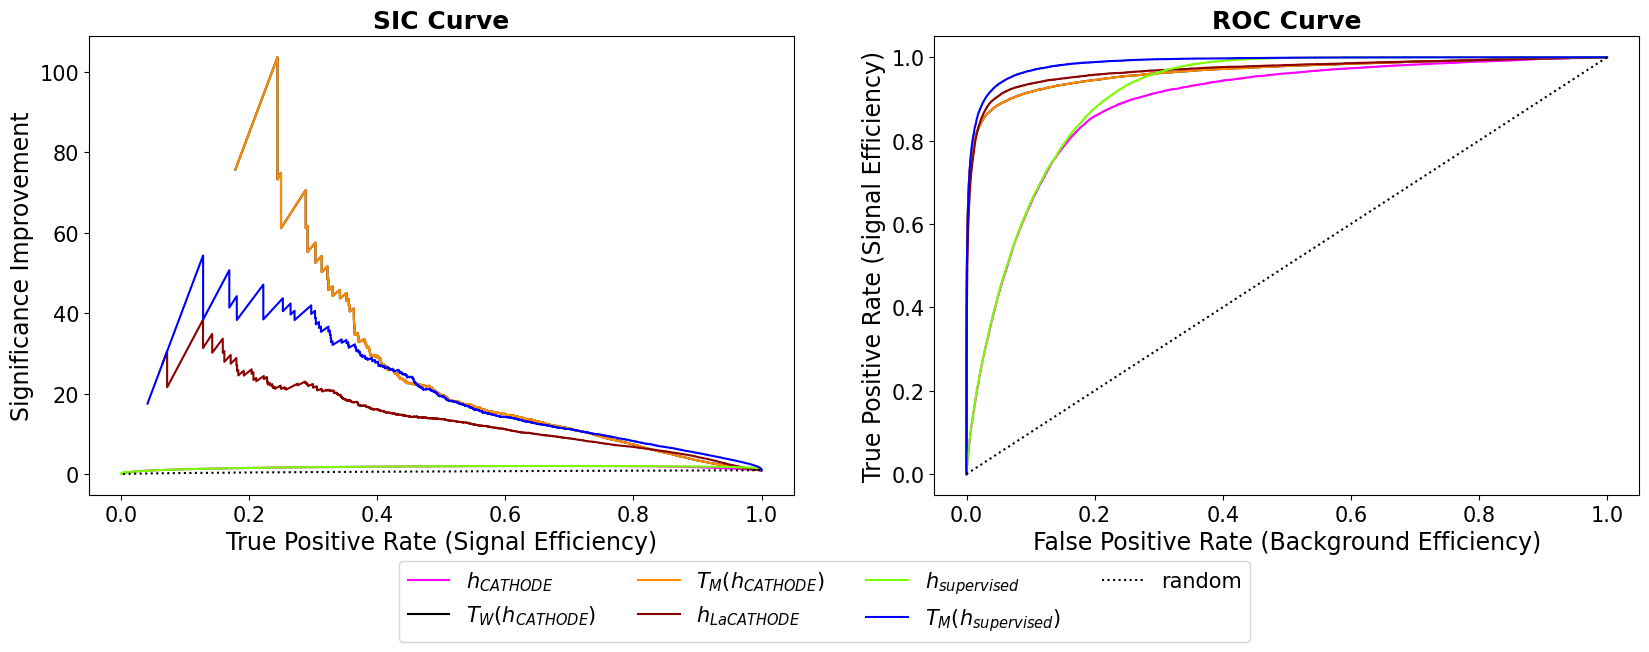

In [9]:
fig, axs = plt.subplots(1,2, figsize = (20,7))

axs[0].plot(h_tpr, h_sic, label="$h_{CATHODE}$", color = "fuchsia")
axs[0].plot(inv_trans_h_tpr, inv_trans_h_sic, label="$T_W(h_{CATHODE})$", color = "black")
axs[0].plot(trans_h_tpr, trans_h_sic, label="$T_M(h_{CATHODE})$", color = "darkorange")

axs[0].plot(la_h_tpr, la_h_sic, label="$h_{LaCATHODE}$", color = "darkred")
axs[0].plot(ideal_h_tpr, ideal_h_sic, label = "$h_{supervised}$", color = "lawngreen")
axs[0].plot(trans_ideal_h_tpr, trans_ideal_h_sic, label = "$T_M(h_{supervised})$", color = "blue")
axs[0].plot(random_tpr, random_sic, "k:", label="random")
axs[0].set_xlabel("True Positive Rate (Signal Efficiency)", fontsize = 17)
axs[0].set_ylabel("Significance Improvement", fontsize = 17)
axs[0].set_title("SIC Curve", fontsize = 18, fontweight = "bold")

# Axis numbers font size
axs[0].tick_params(axis='x', labelsize=15)
axs[0].tick_params(axis='y', labelsize=15)


axs[1].plot(h_fpr, h_tpr, label="$h_{CATHODE}$", color = "fuchsia")
axs[1].plot(inv_trans_h_fpr, inv_trans_h_tpr, label="$T_W(h_{CATHODE})$", color = "black")
axs[1].plot(trans_h_fpr, trans_h_tpr, label="$T_M(h_{CATHODE})$", color = "darkorange")

axs[1].plot(la_h_fpr, la_h_tpr, label="$h_{LaCATHODE}$", color = "darkred")
axs[1].plot(ideal_h_fpr, ideal_h_tpr, label = "$h_{supervised}$", color = "lawngreen")
axs[1].plot(trans_ideal_h_fpr, trans_ideal_h_tpr, label = "$T_M(h_{supervised})$", color = "blue")
axs[1].plot(random_tpr, random_tpr, "k:", label="random")
axs[1].set_xlabel("False Positive Rate (Background Efficiency)", fontsize = 17)
axs[1].set_ylabel("True Positive Rate (Signal Efficiency)", fontsize = 17)
axs[1].set_title("ROC Curve", fontsize = 18, fontweight = "bold")

# Axis numbers font size
axs[1].tick_params(axis='x', labelsize=15)
axs[1].tick_params(axis='y', labelsize=15)

h, l = axs[0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 4, prop={'size': 15})
fig.subplots_adjust(bottom = 0.225)

fig.savefig("SIC_ROC_Correlated", bbox_inches = "tight")

plt.show()

In [ ]:
n = 20
thresholds = np.linspace(0.1, 0.9, n)
classifiers = ("h", "trans_h", "la_h", "ideal_h", "trans_ideal_h")

# Shape: (n_classifiers, n_thresholds)
lambdas    = np.zeros((len(classifiers), n))
dist_corrs = np.zeros((len(classifiers), n))

for ci, h in enumerate(classifiers):
    scores = test_df[h].values
    signal = test_df["signal"].values
    mass   = test_df["m"].values

    # Precompute all quantile cuts at once — shape (n,)
    quantile_cuts = np.quantile(scores, thresholds)

    # Sort once so threshold application becomes a simple slice
    sort_idx      = np.argsort(scores)
    sorted_scores = scores[sort_idx]
    sorted_signal = signal[sort_idx]
    sorted_mass   = mass[sort_idx]

    # Binary search to find cut index for each threshold — shape (n,)
    cut_indices = np.searchsorted(sorted_scores, quantile_cuts, side="left")

    for i, cut in enumerate(cut_indices):
        sig      = sorted_signal[cut:]
        mass_cut = sorted_mass[cut:]
        h_cut    = sorted_scores[cut:]

        n_sig = np.sum(sig == 1)
        n_bkg = np.sum(sig == 0)

        lambdas[ci, i]    = n_sig / n_bkg if n_bkg > 0 else np.nan
        dist_corrs[ci, i] = dcor.distance_correlation(h_cut, mass_cut, method = "avl")

/Users/hamzashah/anaconda3/envs/sk_cathode_env/lib/python3.10/site-packages/dcor/_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(float32, 1d, C), array(float64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(


NameError: name 'colours' is not defined

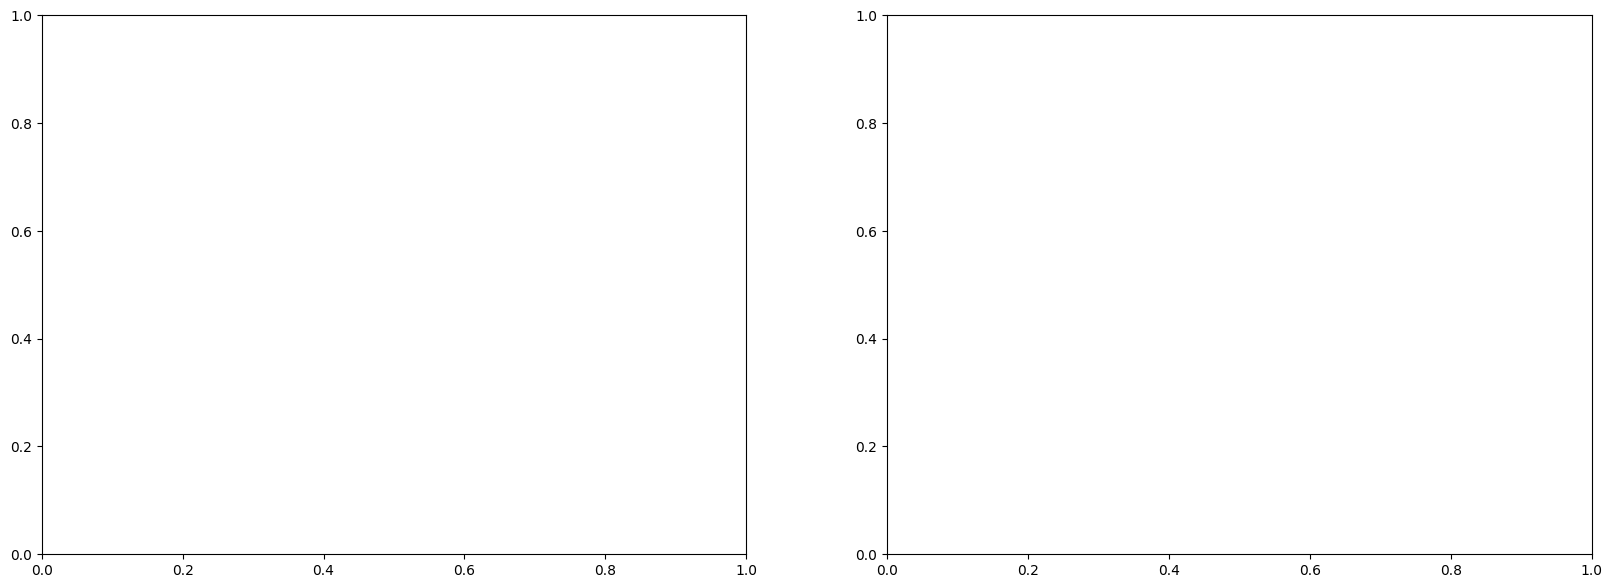

In [13]:
colours = ("fuchsia", "darkorange", "darkred", "lawngreen", "blue")
labels = ("CATHODE", "CATHODE+CDOT", "LaCATHODE", "Supervised", "Supervised+CDOT")

fig, axs = plt.subplots(1,2, figsize = (20,7))

for i in range(len(classifiers)):
    axs[0].plot(lambdas[i], dist_corrs[i], color=colours[i], label=labels[i])

axs[0].set_xlabel("Signal-to-Background Ratio ($\lambda$)", fontsize=10)
axs[0].set_ylabel("Distance Correlation", fontsize=10)


axs[1].plot(h_fpr, h_tpr, label="$h_{CATHODE}$", color = "fuchsia")
axs[1].plot(inv_trans_h_fpr, inv_trans_h_tpr, label="$T_W(h_{CATHODE})$", color = "black")
axs[1].plot(trans_h_fpr, trans_h_tpr, label="$T_M(h_{CATHODE})$", color = "darkorange")

axs[1].plot(la_h_fpr, la_h_tpr, label="$h_{LaCATHODE}$", color = "darkred")
axs[1].plot(ideal_h_fpr, ideal_h_tpr, label = "$h_{supervised}$", color = "lawngreen")
axs[1].plot(trans_ideal_h_fpr, trans_ideal_h_tpr, label = "$T_M(h_{supervised})$", color = "blue")
axs[1].plot(random_tpr, random_tpr, "k:", label="random")
axs[1].set_xlabel("False Positive Rate (Background Efficiency)", fontsize = 15)
axs[1].set_ylabel("True Positive Rate (Signal Efficiency)", fontsize = 15)
axs[1].set_title("ROC Curve", fontsize = 15, fontweight = "bold")

h, l = axs[0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2, prop={'size': 11})
fig.subplots_adjust(bottom = 0.2)

fig.savefig("DisCo_ROC_Correlated", bbox_inches = "tight")

plt.show()

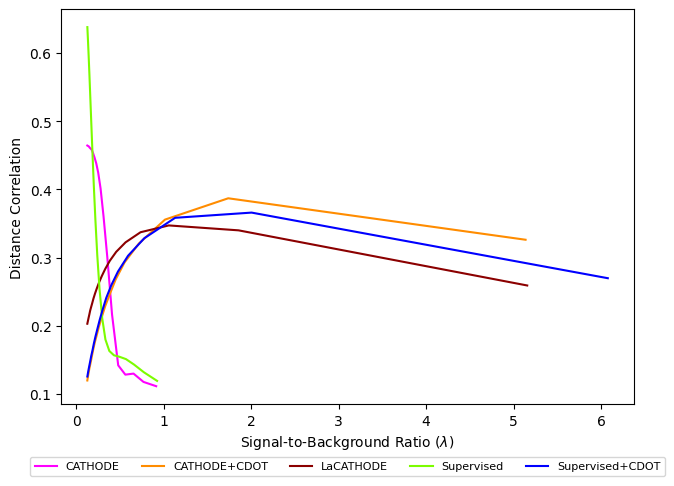

In [17]:
colours = ("fuchsia", "darkorange", "darkred", "lawngreen", "blue")
labels = ("CATHODE", "CATHODE+CDOT", "LaCATHODE", "Supervised", "Supervised+CDOT")

fig, ax = plt.subplots(figsize=(7, 5))

for i in range(len(classifiers)):
    ax.plot(lambdas[i], dist_corrs[i], color=colours[i], label=labels[i])

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=len(classifiers),
    fontsize=8,
    markerscale=0.8,
)
ax.set_xlabel("Signal-to-Background Ratio ($\lambda$)", fontsize=10)
ax.set_ylabel("Distance Correlation", fontsize=10)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)



plt.show()

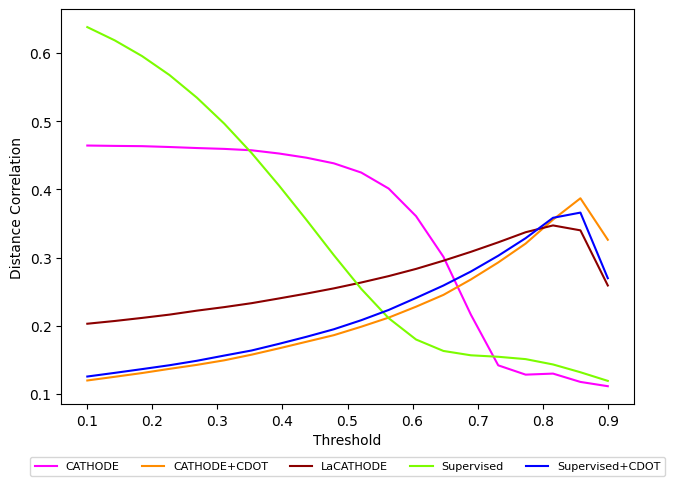

In [18]:
colours = ("fuchsia", "darkorange", "darkred", "lawngreen", "blue")
labels = ("CATHODE", "CATHODE+CDOT", "LaCATHODE", "Supervised", "Supervised+CDOT")

fig, ax = plt.subplots(figsize=(7, 5))

for i in range(len(classifiers)):
    ax.plot(thresholds, dist_corrs[i], color=colours[i], label=labels[i])

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=len(classifiers),
    fontsize=8,
    markerscale=0.8,
)
ax.set_xlabel("Threshold", fontsize=10)
ax.set_ylabel("Distance Correlation", fontsize=10)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()